Goal, simplify the viz as much as possible

In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

from gamma.artifacts import ArtifactStore

In [3]:
### For Viz
#Default plot parameters
pltmap = plt.get_cmap("tab10")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

Keeping track of labels defined in other notebook:

"Experiments"
- `ANIL_MIX_SD__agg__bkgsub`
- `ANIL_AC_SD__agg__bkgsub`
- `WENJO_CE_SD__agg__bkgsub__nobkgrows`
- `ANIL_CE_SD__agg__bkgsub`

"Cal tag"

- `'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'` Anil Ce-134, Wenjo Ce-134, Anil Ac-225 and Anil Mix all had the same cal_tag

Efficiency curve

- `"ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ce-134
- `"ce134_wenjoSD_resp_200-1250keV_cpm_nCi_np_v1"` just Wenjo Ce-134
- `"ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ac-225
- `"ce134_resp_200-1250keV_cpm_nCi_np_v1"` Wenjo + Anil Ce-134

In [4]:
store = ArtifactStore(repo_root / "artifacts")

In [5]:
# Define Ac ground_truth
exp_id = 'ANIL_AC_SD__agg__bkgsub'

truth_ac = store.load_ground_truth(exp_id)  # e.g: exp_id = "ANIL_MIX_SD__agg__bkgsub"
truth_labels_ac = truth_ac["labels"]

In [6]:
truth_labels_ac

{'1000': {'ac225': {'value': 37000.0, 'sigma': None}},
 '500': {'ac225': {'value': 18500.0, 'sigma': None}},
 '250': {'ac225': {'value': 9250.0, 'sigma': None}},
 '125': {'ac225': {'value': 4625.0, 'sigma': None}},
 '62.5': {'ac225': {'value': 2312.5, 'sigma': None}},
 '31.25': {'ac225': {'value': 1156.25, 'sigma': None}},
 '15.625': {'ac225': {'value': 578.125, 'sigma': None}},
 '7.8125': {'ac225': {'value': 289.0625, 'sigma': None}},
 '3.90625': {'ac225': {'value': 144.53125, 'sigma': None}},
 '1.953125': {'ac225': {'value': 72.265625, 'sigma': None}}}

In [7]:
runs_ac = store.mle_runs_table(exp_id)  # ALWAYS a DataFrame
print('shape', runs_ac.shape)
runs_ac.head()

shape (100, 12)


,activity_units,eff_models,experiment_id,fit_success,label,method_tag,nll2,npz_exists,roi_keV,run_id,saved_at,templates
0,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,1.95312,poisson_mle_v1,1.072125e-09,True,"[200, 1250]",mle_poisson_v1__c675798626,2026-02-18T00:09:11.718420+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...
1,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,1.95312,poisson_mle_v1,3.105229e+02,True,"[200, 1250]",mle_poisson_v1__42153c4c2c,2026-02-18T00:09:12.912008+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...
2,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,1.95312,poisson_mle_v1,3.231863e+02,True,"[200, 1250]",mle_poisson_v1__dea93c4858,2026-02-18T00:09:13.862429+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...
3,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,1.95312,poisson_mle_v1,7.250414e+02,True,"[200, 1250]",mle_poisson_v1__979534cebd,2026-02-18T00:09:14.668528+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...
4,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,1.95312,poisson_mle_v1,3.205062e+02,True,"[200, 1250]",mle_poisson_v1__999896ba44,2026-02-18T00:09:17.249465+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...


In [8]:
def ac_flatten_mle_runs_df(df):
    df = df.copy()

    def get_template(df_row, iso, key):
        t = df_row.get("templates")
        if isinstance(t, dict):
            ti = t.get(iso)
            if isinstance(ti, dict):
                return ti.get(key)
        return None

    def get_eff(df_row, iso):
        e = df_row.get("eff_models")
        if isinstance(e, dict):
            return e.get(iso)
        return None

    # Template provenance
    # df["ce_template_label"] = df.apply(lambda r: get_template(r, "ce134", "label"), axis=1)
    df["ac_template_label"] = df.apply(lambda r: get_template(r, "ac225", "label"), axis=1)

    # df["ce_template_exp_id"] = df.apply(lambda r: get_template(r, "ce134", "experiment_id"), axis=1)
    df["ac_template_exp_id"] = df.apply(lambda r: get_template(r, "ac225", "experiment_id"), axis=1)

    # df["ce_cal_tag"] = df.apply(lambda r: get_template(r, "ce134", "cal_tag"), axis=1)
    df["ac_cal_tag"] = df.apply(lambda r: get_template(r, "ac225", "cal_tag"), axis=1)

    # Efficiency model names
    # df["ce_eff_name"] = df.apply(lambda r: get_eff(r, "ce134"), axis=1)
    df["ac_eff_name"] = df.apply(lambda r: get_eff(r, "ac225"), axis=1)

    return df
    
### There might be a duplciate get-activity
def get_activity(row, iso):
    est = store.load_mle_estimate(row["experiment_id"], row["label"], run_id=row["run_id"])
    return est.activities_bq.get(iso)

In [9]:
runs_flat = ac_flatten_mle_runs_df(runs_ac)

# runs_flat[[
#     "label", "run_id",
#     "ce_template_label",
#     "ce_eff_name",
#     "roi_keV", "method_tag"
# ]].head()

# -> This should be isnerted into `ac_flatten_mle_runs_df``
runs_flat["ac225_activity_bq"] = runs_flat.apply(lambda r: get_activity(r, "ac25"), axis=1)

In [10]:
display(runs_flat)

,activity_units,eff_models,experiment_id,fit_success,label,method_tag,nll2,npz_exists,roi_keV,run_id,saved_at,templates,ac_template_label,ac_template_exp_id,ac_cal_tag,ac_eff_name,ac225_activity_bq
0,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,1.95312,poisson_mle_v1,1.072125e-09,True,"[200, 1250]",mle_poisson_v1__c675798626,2026-02-18T00:09:11.718420+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,1.95312,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,None
1,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,1.95312,poisson_mle_v1,3.105229e+02,True,"[200, 1250]",mle_poisson_v1__42153c4c2c,2026-02-18T00:09:12.912008+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,1000,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,None
2,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,1.95312,poisson_mle_v1,3.231863e+02,True,"[200, 1250]",mle_poisson_v1__dea93c4858,2026-02-18T00:09:13.862429+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,125,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,None
3,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,1.95312,poisson_mle_v1,7.250414e+02,True,"[200, 1250]",mle_poisson_v1__979534cebd,2026-02-18T00:09:14.668528+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,15.625,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,None
4,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,1.95312,poisson_mle_v1,3.205062e+02,True,"[200, 1250]",mle_poisson_v1__999896ba44,2026-02-18T00:09:17.249465+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,250,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,7.8125,poisson_mle_v1,2.547590e+03,True,"[200, 1250]",mle_poisson_v1__9d9778c512,2026-02-18T00:10:37.657609+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,3.90625,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,None
96,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,7.8125,poisson_mle_v1,7.082751e+02,True,"[200, 1250]",mle_poisson_v1__03ca2c6239,2026-02-18T00:10:38.462198+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,31.25,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,None
97,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,7.8125,poisson_mle_v1,3.151134e+02,True,"[200, 1250]",mle_poisson_v1__0355c9e33a,2026-02-18T00:10:39.354993+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,500,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,None
98,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_AC_SD__agg__bkgsub,True,7.8125,poisson_mle_v1,3.481314e+02,True,"[200, 1250]",mle_poisson_v1__f46c2325cb,2026-02-18T00:10:39.955595+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,62.5,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,None


In [11]:
#-> this is a generic function that error propagates 
def percent_dev_and_sigma(est_bq, est_sigma_bq, truth_bq, truth_sigma_bq=None):
    if est_bq is None or truth_bq is None or truth_bq == 0:
        return (np.nan, np.nan)
    dev = 100.0 * (est_bq - truth_bq) / truth_bq

    # sigma propagation
    terms = []
    if est_sigma_bq is not None and np.isfinite(est_sigma_bq):
        terms.append((est_sigma_bq / truth_bq) ** 2)

    if truth_sigma_bq is not None and np.isfinite(truth_sigma_bq) and truth_sigma_bq != 0:
        terms.append(((est_bq * truth_sigma_bq) / (truth_bq ** 2)) ** 2)

    sig = 100.0 * np.sqrt(np.sum(terms)) if terms else np.nan
    return dev, sig

ac225_devs = []
ac225_sigs = []
ac225_est_sig_vals = []

ISO = "ac225"

for _, r in runs_flat.iterrows():
    label = r["label"]
    run_id = r["run_id"]

    est = store.load_mle_estimate(exp_id, label, run_id=run_id)

    est_bq = est.activities_bq.get(ISO)
    est_sigma_bq = None
    if est.uncertainties_bq is not None:
        est_sigma_bq = est.uncertainties_bq.get(ISO)

    # truth lookup
    # print('label', label)
    if label=='1.95312':
        truth_label = '1.953125'
    else:
        truth_label = label
        
    t = truth_ac['labels'].get(truth_label, {}).get(ISO, None)
    # print(t)
    if t is None:
        dev, sig = (np.nan, np.nan)
    else:
        truth_bq = t.get("value")
        truth_sigma_bq = t.get("sigma", None)
        dev, sig = percent_dev_and_sigma(est_bq, est_sigma_bq, truth_bq, truth_sigma_bq)

    # est_vals.append(est_bq)
    ac225_est_sig_vals.append(est_sigma_bq)
    ac225_devs.append(dev)
    ac225_sigs.append(sig)

# runs_flat["est_bq"] = est_vals
runs_flat[f"{ISO}_est_sigma_bq"] = ac225_est_sig_vals
runs_flat[f"{ISO}_percent_dev"] = ac225_devs
runs_flat[f"{ISO}_percent_dev_sigma"] = ac225_sigs

Displaying the percent deviation of MLE estimates on ac225


C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


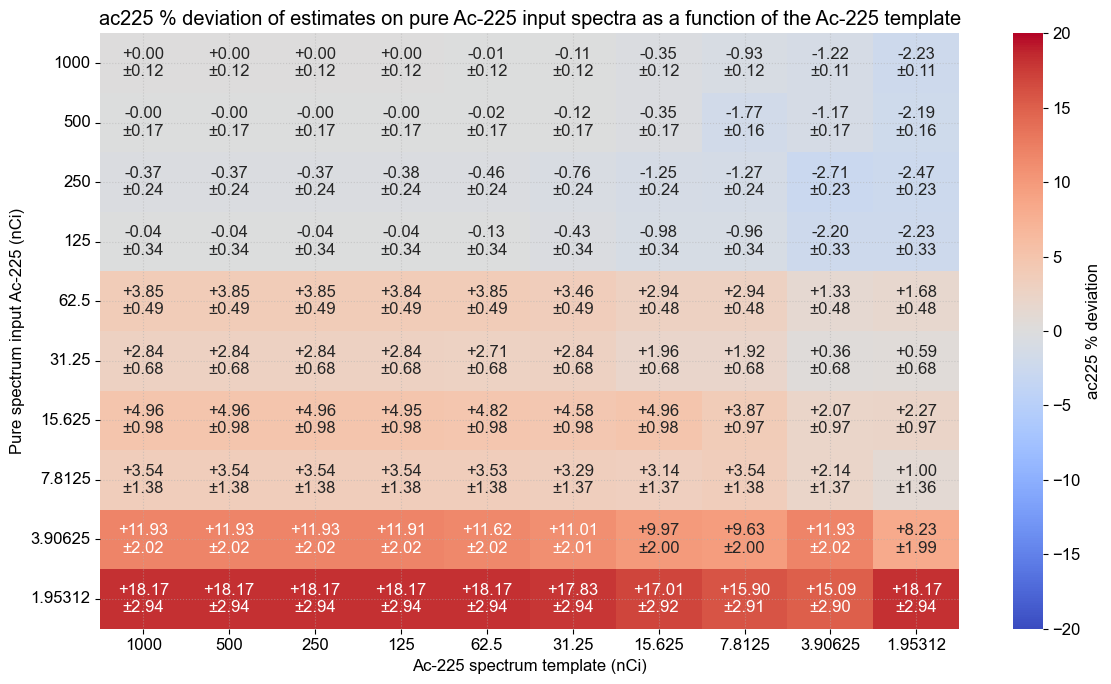

In [12]:
# seaborn method 
ISO = "ac225"

print(f'Displaying the percent deviation of MLE estimates on {ISO}')

sub = runs_flat[ 
    (runs_flat["method_tag"] == "poisson_mle_v1") &
    (runs_flat['ac_eff_name'] == 'ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1') 
    ]

val = sub.pivot_table(
    index="label",                  # X-axis / rows = mixed samples
    columns="ac_template_label",    # Y-axis / columns = Ce template choices
    values=f"{ISO}_percent_dev",           # cell = percent deviation on Ce activity (determined from `percent_dev_and_sigma`)
    aggfunc="mean"                  # if duplicates exist ... Oh?
)

sig = sub.pivot_table(
    index="label",
    columns="ac_template_label",
    values=f"{ISO}_percent_dev_sigma",
    aggfunc="mean"
)

y_order = ["1000", "500", "250", "125", "62.5", "31.25", "15.625", "7.8125", "3.90625", "1.95312"]
x_order = ["1000", "500", "250", "125", "62.5", "31.25", "15.625", "7.8125", "3.90625", "1.95312"]

val = val.reindex(index=y_order, columns=x_order)
sig = sig.reindex(index=y_order, columns=x_order)

annot = val.copy().astype(object)

for i in range(val.shape[0]):
    for j in range(val.shape[1]):
        v = val.iat[i, j]
        s = sig.iat[i, j] if sig is not None else np.nan

        if not np.isfinite(v):
            annot.iat[i, j] = ""
        else:
            if np.isfinite(s):
                annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
            else:
                annot.iat[i, j] = f"{v:+.2f}"

vmin, vmax = -20, 20

plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    val,
    annot=annot,
    fmt="",              # IMPORTANT: fmt empty because annot is strings
    center=0,            # percent deviation: center at 0
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": f"{ISO} % deviation"}
)
ax.set_xlabel("Ac-225 spectrum template (nCi)")
ax.set_ylabel("Pure spectrum input Ac-225 (nCi)")
ax.set_title(f"{ISO} % deviation of estimates on pure Ac-225 input spectra as a function of the Ac-225 template")
plt.tight_layout()
plt.show()

Displaying the percent deviation of MLE estimates on ac225


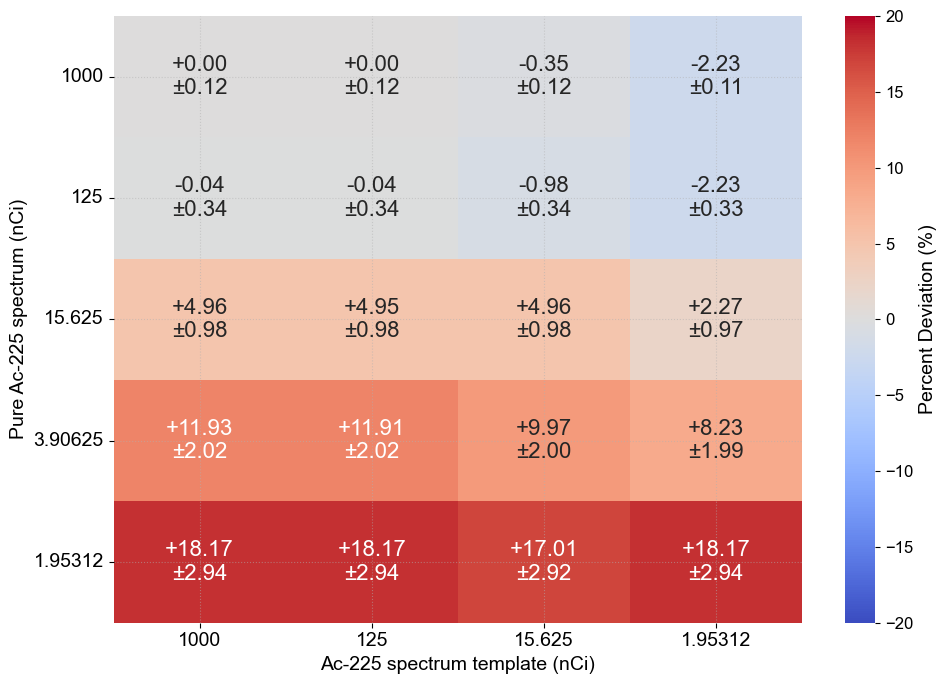

In [13]:
# seaborn method 
ISO = "ac225"

print(f'Displaying the percent deviation of MLE estimates on {ISO}')

sub = runs_flat[ 
    (runs_flat["method_tag"] == "poisson_mle_v1") &
    (runs_flat['ac_eff_name'] == 'ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1') &
    ((runs_flat['label']=='1000')|(runs_flat['label']=='125')|(runs_flat['label']=='15.625')|(runs_flat['label']=='3.90625')|(runs_flat['label']=='1.95312')) & # narrowing down Y-axis
    ((runs_flat['ac_template_label']=='1000')|(runs_flat['ac_template_label']=='125')|(runs_flat['ac_template_label']=='15.625')|(runs_flat['ac_template_label']=='1.95312')) # narrowing down X-axis
].copy()

val = sub.pivot_table(
    index="label",                  # X-axis / rows = mixed samples
    columns="ac_template_label",    # Y-axis / columns = Ce template choices
    values=f"{ISO}_percent_dev",           # cell = percent deviation on Ce activity (determined from `percent_dev_and_sigma`)
    aggfunc="mean"                  # if duplicates exist ... Oh?
)

sig = sub.pivot_table(
    index="label",
    columns="ac_template_label",
    values=f"{ISO}_percent_dev_sigma",
    aggfunc="mean"
)

y_order = ["1000", "125", "15.625","3.90625", "1.95312"]
x_order = ["1000", "125", "15.625", "1.95312"]

val = val.reindex(index=y_order, columns=x_order)
sig = sig.reindex(index=y_order, columns=x_order)

annot = val.copy().astype(object)

for i in range(val.shape[0]):
    for j in range(val.shape[1]):
        v = val.iat[i, j]
        s = sig.iat[i, j] if sig is not None else np.nan

        if not np.isfinite(v):
            annot.iat[i, j] = ""
        else:
            if np.isfinite(s):
                annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
            else:
                annot.iat[i, j] = f"{v:+.2f}"

vmin, vmax = -20, 20

plt.figure(figsize=(10, 7))
ax = sns.heatmap(
    val,
    annot=annot,
    fmt="",              # IMPORTANT: fmt empty because annot is strings
    center=0,            # percent deviation: center at 0
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    annot_kws={"size": 16},
    cbar_kws={"label": f"{ISO} % deviation"}
)


ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

cbar = ax.collections[0].colorbar
cbar.set_label("Percent Deviation (%)", fontsize=14)

ax.set_xlabel("Ac-225 spectrum template (nCi)", fontsize=14)
ax.set_ylabel("Pure Ac-225 spectrum (nCi)", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)


plt.tight_layout()
plt.show()

# Load Cut and Count Pure Ac estimations

In [14]:
exp_ac = exp_id
df_cc_ac = store.cutcount_runs_table(exp_ac).copy()

# Flatten nested dict columns into scalar columns
df_cc_ac["ac_template_label"] = df_cc_ac["templates"].apply(
    lambda d: d.get("ac225", {}).get("label") if isinstance(d, dict) else None
)

df_cc_ac["ac_eff_name"] = df_cc_ac["eff_models"].apply(
    lambda d: d.get("ac", {}).get("name") if isinstance(d, dict) else None
)

# (Optional) model type too
df_cc_ac["ac_eff_type"] = df_cc_ac["eff_models"].apply(
    lambda d: d.get("ac", {}).get("type") if isinstance(d, dict) else None
)

df_cc_ac.shape

(10, 13)

In [15]:
df_cc_ac

,activity_units,eff_models,experiment_id,label,method_tag,npz_exists,roi_keV,run_id,saved_at,templates,ac_template_label,ac_eff_name,ac_eff_type
0,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,1.95312,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.241794+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable
1,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,1000,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.246193+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable
2,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,125,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.250981+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable
3,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,15.625,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.259275+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable
4,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,250,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.264617+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable
5,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,3.90625,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.269547+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable
6,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,31.25,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.275188+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable
7,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,500,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.280650+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable
8,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,62.5,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.286742+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable
9,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,7.8125,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.292694+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable


In [16]:
def percent_dev(est, truth):
    return 100.0 * (est - truth) / truth

def get_truth_bq(label, iso, truth_dic):
    d = truth_dic.get(label, {})
    if iso not in d:
        return np.nan
    v = d[iso].get("value", None)
    return float(v) if v is not None else np.nan

rows = []
for _, r in df_cc_ac.iterrows():
    label = r["label"]
    run_id = r["run_id"]
    est = store.load_cutcount_estimate(exp_ac, label, run_id=run_id)

    row = r.to_dict()

    for ISO in ["ac225"]:
        Ahat = est.activities_bq.get(ISO, np.nan)
        sigA = (est.uncertainties_bq or {}).get(ISO, np.nan)

        if label=='1.95312':
            truth_label = '1.953125'
        else:
            truth_label = label

        Atrue = get_truth_bq(truth_label, ISO, truth_labels_ac)

        pdv = percent_dev(Ahat, Atrue) if np.isfinite(Ahat) and np.isfinite(Atrue) and Atrue != 0 else np.nan
        pdv_sig = 100.0 * sigA / Atrue if np.isfinite(sigA) and np.isfinite(Atrue) and Atrue != 0 else np.nan

        row.update({
            f"{ISO}_truth_bq": Atrue,
            f"{ISO}_est_bq": Ahat,
            f"{ISO}_est_sigma_bq": sigA,
            f"{ISO}_percent_dev": pdv,
            f"{ISO}_percent_dev_sigma": pdv_sig,
        })

    rows.append(row)

runs_cc_flat = pd.DataFrame(rows)
runs_cc_flat.head()

,activity_units,eff_models,experiment_id,label,method_tag,npz_exists,roi_keV,run_id,saved_at,templates,ac_template_label,ac_eff_name,ac_eff_type,ac225_truth_bq,ac225_est_bq,ac225_est_sigma_bq,ac225_percent_dev,ac225_percent_dev_sigma
0,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,1.95312,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.241794+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable,72.265625,77.428755,4.725334,7.144656,6.538840
1,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,1000,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.246193+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable,37000.000000,33986.447555,99.352038,-8.144736,0.268519
2,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,125,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.250981+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable,4625.000000,4402.638980,35.647973,-4.807806,0.770767
3,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,15.625,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.259275+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable,578.125000,574.386558,12.870817,-0.646649,2.226303
4,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_AC_SD__agg__bkgsub,250,cutcount_single_v1,True,None,cutcount_single_v1__d7dada6193,2026-02-19T15:25:06.264617+00:00,None,None,ac225_win_counts60s_v2,nonparalyzable,9250.000000,8845.196749,50.551529,-4.376251,0.546503


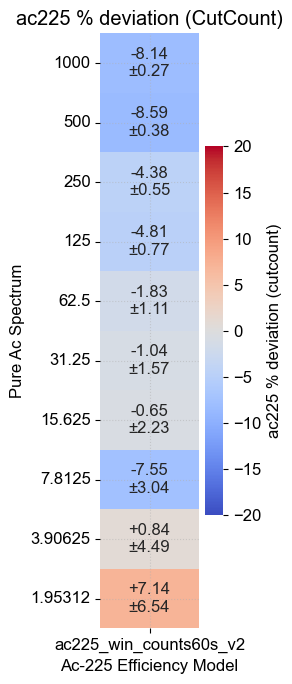

In [17]:
sub = runs_cc_flat[
    (runs_cc_flat["method_tag"] == "cutcount_single_v1") &
    (runs_cc_flat["ac_eff_name"] == 'ac225_win_counts60s_v2')
    # ((runs_cc_flat['label']=='1000')|(runs_cc_flat['label']=='125')|(runs_cc_flat['label']=='15.625')|(runs_cc_flat['label']=='3.90625')|(runs_cc_flat['label']=='1.95312')) # narrowing down Y-axis
].copy()


for ISO in ["ac225"]:
    val = sub.pivot_table(
        index="label",
        columns="ac_eff_name",
        values=f"{ISO}_percent_dev",
        aggfunc="mean",
    )

    sig = sub.pivot_table(
        index="label",
        columns="ac_eff_name",
        values=f"{ISO}_percent_dev_sigma",
        aggfunc="mean",
    )

    # Reorder axes (use your existing orders)
    y_order = ["1000", "500", "250", "125", "62.5", "31.25",
            "15.625", "7.8125", "3.90625", "1.95312"]
    x_order = ['ac225_win_counts60s_v2']

    val = val.reindex(index=y_order, columns=x_order)
    sig = sig.reindex(index=y_order, columns=x_order)

    annot = val.copy().astype(object)

    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iat[i, j]
            s = sig.iat[i, j]
            if not np.isfinite(v):
                annot.iat[i, j] = ""
            else:
                if np.isfinite(s):
                    annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
                else:
                    annot.iat[i, j] = f"{v:+.2f}"

    vmin, vmax = -20, 20

    plt.figure(figsize=(3, 7))
    ax = sns.heatmap(
        val,
        annot=annot,
        fmt="",
        center=0,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        cbar_kws={"label": f"{ISO} % deviation (cutcount)"}
    )
    ax.set_xlabel("Ac-225 Efficiency Model")
    ax.set_ylabel("Pure Ac Spectrum")
    ax.set_title(f"{ISO} % deviation (CutCount)")
    plt.tight_layout()
    plt.show()


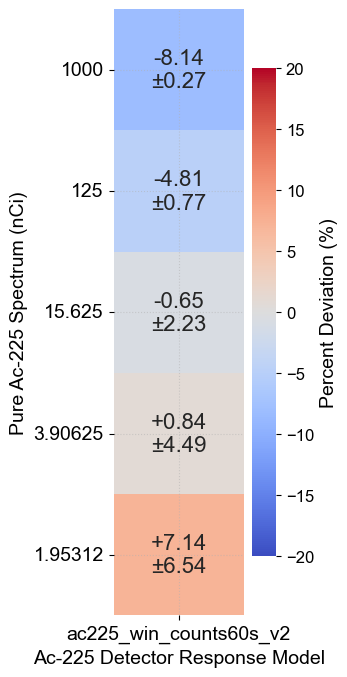

In [18]:
sub = runs_cc_flat[
    (runs_cc_flat["method_tag"] == "cutcount_single_v1") &
    (runs_cc_flat["ac_eff_name"] == 'ac225_win_counts60s_v2')
].copy()


for ISO in ["ac225"]:
    val = sub.pivot_table(
        index="label",
        columns="ac_eff_name",
        values=f"{ISO}_percent_dev",
        aggfunc="mean",
    )

    sig = sub.pivot_table(
        index="label",
        columns="ac_eff_name",
        values=f"{ISO}_percent_dev_sigma",
        aggfunc="mean",
    )

    # Reorder axes (use your existing orders)
    y_order = ["1000", "125", "15.625","3.90625", "1.95312"]
    x_order = ['ac225_win_counts60s_v2']

    val = val.reindex(index=y_order, columns=x_order)
    sig = sig.reindex(index=y_order, columns=x_order)

    annot = val.copy().astype(object)

    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iat[i, j]
            s = sig.iat[i, j]
            if not np.isfinite(v):
                annot.iat[i, j] = ""
            else:
                if np.isfinite(s):
                    annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
                else:
                    annot.iat[i, j] = f"{v:+.2f}"

    vmin, vmax = -20, 20

    plt.figure(figsize=(3.5, 7))
    ax = sns.heatmap(
        val,
        annot=annot,
        fmt="",
        center=0,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        annot_kws={"size": 16},
        cbar_kws={"label": f"{ISO} % deviation (cutcount)"}
    )

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    cbar = ax.collections[0].colorbar
    cbar.set_label("Percent Deviation (%)", fontsize=14)

    ax.set_xlabel("Ac-225 Detector Response Model", fontsize=14)
    ax.set_ylabel("Pure Ac-225 Spectrum (nCi)", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout()
    plt.show()


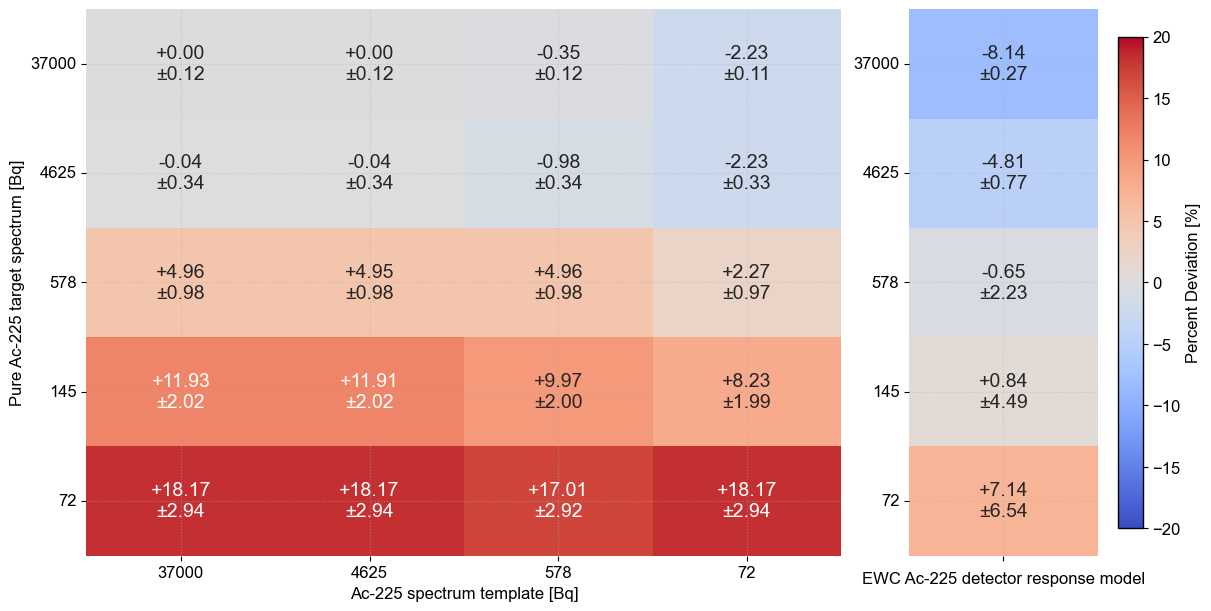

: 

In [23]:

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 6),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [4, 1]}
)

ISO = "ac225"
vmin, vmax = -20, 20

############################################
# LEFT PANEL (MLE heatmap)
############################################

sub = runs_flat[
    (runs_flat["method_tag"] == "poisson_mle_v1") &
    (runs_flat['ac_eff_name'] == 'ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1') &
    ((runs_flat['label']=='1000')|(runs_flat['label']=='125')|(runs_flat['label']=='15.625')|
     (runs_flat['label']=='3.90625')|(runs_flat['label']=='1.95312')) &
    ((runs_flat['ac_template_label']=='1000')|(runs_flat['ac_template_label']=='125')|
     (runs_flat['ac_template_label']=='15.625')|(runs_flat['ac_template_label']=='1.95312'))
].copy()

val_left = sub.pivot_table(
    index="label",
    columns="ac_template_label",
    values=f"{ISO}_percent_dev",
    aggfunc="mean"
)

sig_left = sub.pivot_table(
    index="label",
    columns="ac_template_label",
    values=f"{ISO}_percent_dev_sigma",
    aggfunc="mean"
)

y_order = ["1000", "125", "15.625", "3.90625", "1.95312"]
x_order_left = ["1000", "125", "15.625", "1.95312"]

y_order_disp = ["37000", "4625", "578", "145", "72"]
x_order_disp = ["37000", "4625", "578", "72"]

val_left = val_left.reindex(index=y_order, columns=x_order_left)
sig_left = sig_left.reindex(index=y_order, columns=x_order_left)

annot_left = val_left.copy().astype(object)
for i in range(val_left.shape[0]):
    for j in range(val_left.shape[1]):
        v = val_left.iat[i, j]
        s = sig_left.iat[i, j]
        if not np.isfinite(v):
            annot_left.iat[i, j] = ""
        else:
            annot_left.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"

hm_left = sns.heatmap(
    val_left,
    annot=annot_left,
    fmt="",
    center=0,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    ax=axes[0],
    annot_kws={"size": 14},
    cbar=False,
    yticklabels=y_order_disp,
    xticklabels=x_order_disp,
)

# axes[0].set_title("MLE Template Selection")
axes[0].set_xlabel("Ac-225 spectrum template [Bq]")
axes[0].set_ylabel("Pure Ac-225 target spectrum [Bq]")
axes[0].tick_params(axis='both', labelsize=12)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

############################################
# RIGHT PANEL (EWC heatmap)
############################################

sub = runs_cc_flat[
    (runs_cc_flat["method_tag"] == "cutcount_single_v1") &
    (runs_cc_flat["ac_eff_name"] == 'ac225_win_counts60s_v2')
].copy()

val_right = sub.pivot_table(
    index="label",
    columns="ac_eff_name",
    values=f"{ISO}_percent_dev",
    aggfunc="mean"
)

sig_right = sub.pivot_table(
    index="label",
    columns="ac_eff_name",
    values=f"{ISO}_percent_dev_sigma",
    aggfunc="mean"
)

x_order_right = ['ac225_win_counts60s_v2']

val_right = val_right.reindex(index=y_order, columns=x_order_right)
sig_right = sig_right.reindex(index=y_order, columns=x_order_right)

annot_right = val_right.copy().astype(object)
for i in range(val_right.shape[0]):
    for j in range(val_right.shape[1]):
        v = val_right.iat[i, j]
        s = sig_right.iat[i, j]
        if not np.isfinite(v):
            annot_right.iat[i, j] = ""
        else:
            annot_right.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"

x_placeholder = ['']

hm_right = sns.heatmap(
    val_right,
    annot=annot_right,
    fmt="",
    center=0,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    ax=axes[1],
    annot_kws={"size": 14},
    cbar=False,
    yticklabels=y_order_disp,
    xticklabels=x_placeholder,
)

# axes[1].set_title("Energy Window Counting")
axes[1].set_xlabel("EWC Ac-225 detector response model")
axes[1].set_ylabel("")
axes[1].tick_params(axis='both', labelsize=12)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

############################################
# ONE SHARED COLORBAR
############################################

cbar = fig.colorbar(
    hm_left.collections[0],
    ax=axes,
    shrink=0.9,
    pad=0.02
)
cbar.set_label("Percent Deviation [%]", fontsize=12)

############################################
# SAVE
############################################

# plt.savefig("ac225_method_comparison.png", dpi=300, bbox_inches="tight")
# plt.savefig("ac225_method_comparison.pdf", bbox_inches="tight")
plt.show()

### Visualize and Verify MLE estimates

In [20]:
display(sub.columns)

Index(['activity_units', 'eff_models', 'experiment_id', 'label', 'method_tag',
       'npz_exists', 'roi_keV', 'run_id', 'saved_at', 'templates',
       'ac_template_label', 'ac_eff_name', 'ac_eff_type', 'ac225_truth_bq',
       'ac225_est_bq', 'ac225_est_sigma_bq', 'ac225_percent_dev',
       'ac225_percent_dev_sigma'],
      dtype='object')

In [21]:
sub = runs_flat[ 
    (runs_flat["method_tag"] == "poisson_mle_v1") &
    (runs_flat['ce_eff_name'] == 'ce134_resp_200-1250keV_cpm_nCi_np_v1') &
    (runs_flat['label'] == '250') &
    ((runs_flat['ce_template_label'] == '1.95312') | (runs_flat['ce_template_label'] == '31.25') | (runs_flat['ce_template_label'] == '250') )
    ]

KeyError: 'ce_eff_name'

In [ ]:
display(sub)

,activity_units,eff_models,experiment_id,fit_success,label,method_tag,nll2,npz_exists,roi_keV,run_id,saved_at,templates,ce_template_label,ce_template_exp_id,ce_cal_tag,ce_eff_name,ce134_activity_bq,ce134_est_sigma_bq,ce134_percent_dev,ce134_percent_dev_sigma
40,nci,{'ce134': 'ce134_resp_200-1250keV_cpm_nCi_np_v1'},ANIL_CE_SD__agg__bkgsub,True,250,poisson_mle_v1,7.378558e+04,True,"[200, 1250]",mle_poisson_v1__bb9187363b,2026-02-17T20:10:22.580330+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...,1.95312,ANIL_CE_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ce134_resp_200-1250keV_cpm_nCi_np_v1,8961.952146,16.587926,-3.114031,0.179329
44,nci,{'ce134': 'ce134_resp_200-1250keV_cpm_nCi_np_v1'},ANIL_CE_SD__agg__bkgsub,True,250,poisson_mle_v1,4.366001e-13,True,"[200, 1250]",mle_poisson_v1__6b394f1c4b,2026-02-17T20:10:23.875505+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...,250,ANIL_CE_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ce134_resp_200-1250keV_cpm_nCi_np_v1,8997.272391,16.622361,-2.732190,0.179701
46,nci,{'ce134': 'ce134_resp_200-1250keV_cpm_nCi_np_v1'},ANIL_CE_SD__agg__bkgsub,True,250,poisson_mle_v1,1.591789e+03,True,"[200, 1250]",mle_poisson_v1__f3d17b8ee6,2026-02-17T20:10:24.614836+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...,31.25,ANIL_CE_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ce134_resp_200-1250keV_cpm_nCi_np_v1,8997.272222,16.622069,-2.732192,0.179698



label=250 run_id=mle_poisson_v1__bb9187363b
activities: {'ce134': 8961.952146486592}
uncertainties: {'ce134': 16.587926242339773}


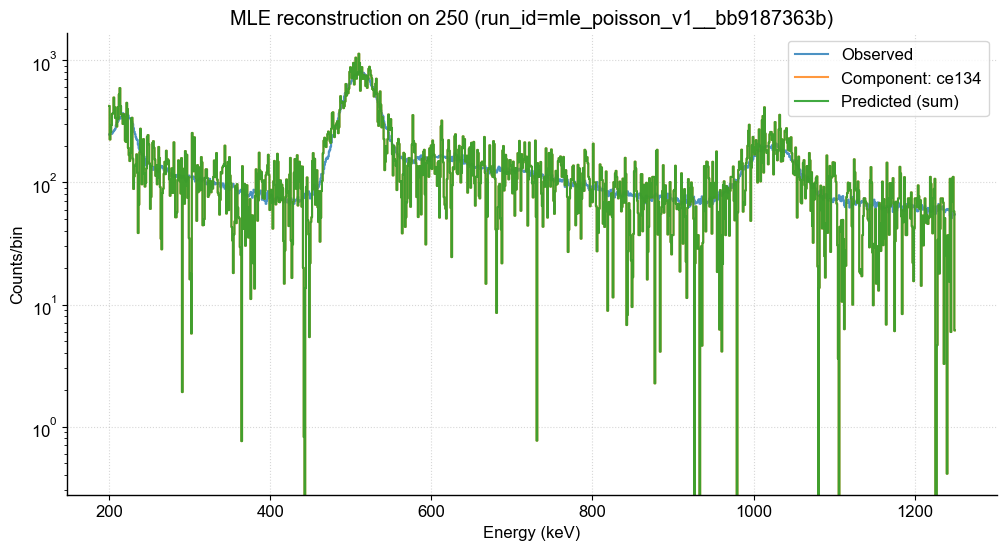


label=250 run_id=mle_poisson_v1__6b394f1c4b
activities: {'ce134': 8997.272390551772}
uncertainties: {'ce134': 16.622361241943572}


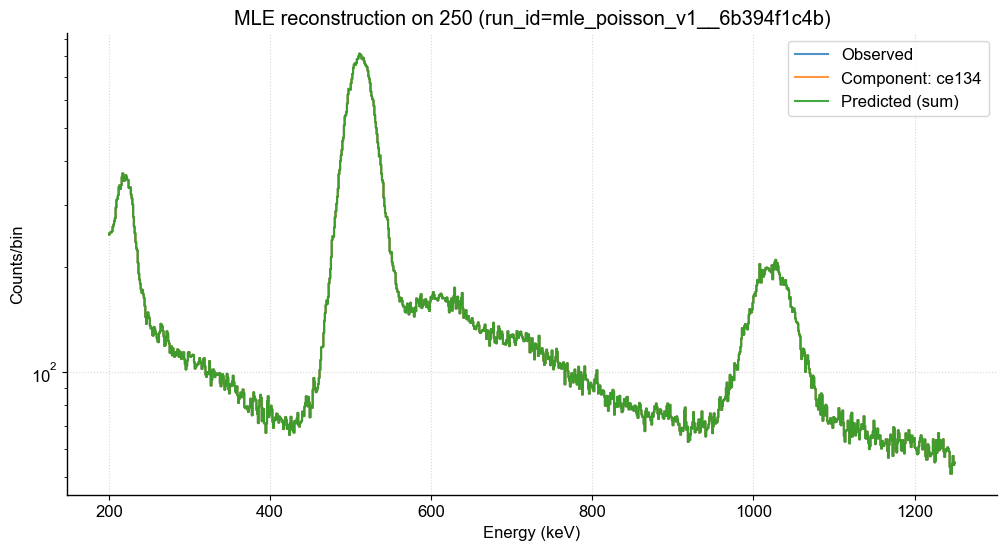


label=250 run_id=mle_poisson_v1__f3d17b8ee6
activities: {'ce134': 8997.272222149206}
uncertainties: {'ce134': 16.62206900114719}


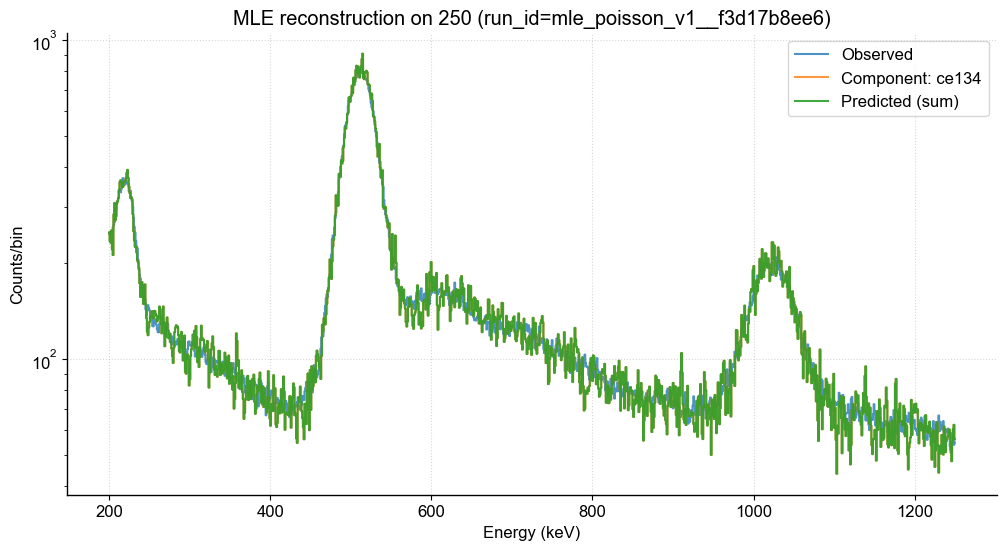

In [ ]:
for row in range(len(sub)):
    zoom_in_row = sub.iloc[row]
    label, run_id = zoom_in_row["label"], zoom_in_row["run_id"]

    est = store.load_mle_estimate(exp_id, label, run_id=run_id)
    arr = store.load_mle_fit_arrays(exp_id, label, run_id=run_id)   # <-- THIS was missing

    print(f"\nlabel={label} run_id={run_id}")
    print("activities:", est.activities_bq)
    print("uncertainties:", est.uncertainties_bq)

    x = arr["x_keV"]
    y_obs = arr["y_obs"]
    y_hat = arr["y_hat"]

    plt.figure()
    plt.step(x, y_obs, where="mid", label="Observed", alpha=0.8)

    for k in sorted(arr.keys()):
        if k.startswith("comp__"):
            iso = k.replace("comp__", "")
            plt.step(x, arr[k], where="mid", label=f"Component: {iso}", alpha=0.8)

    plt.step(x, y_hat, where="mid", label="Predicted (sum)", alpha=0.9)
    plt.yscale("log")
    plt.xlabel("Energy (keV)")
    plt.ylabel("Counts/bin")
    plt.legend()
    plt.title(f"MLE reconstruction on {label} (run_id={run_id})")
    plt.show()


# Load Cut and Count Pure Ce estimations

(10, 13)

In [ ]:
df_cc

,activity_units,eff_models,experiment_id,label,method_tag,npz_exists,roi_keV,run_id,saved_at,templates,ce_template_label,ce_eff_name,ce_eff_type
0,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,1.95312,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.260244+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable
1,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,1000,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.275553+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable
2,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,125,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.282057+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable
3,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,15.625,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.288185+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable
4,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,250,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.293338+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable
5,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,3.90625,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.298492+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable
6,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,31.25,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.303593+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable
7,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,500,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.308507+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable
8,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,62.5,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.308507+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable
9,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,7.8125,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.316792+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable


In [ ]:
# exp_id = 'ANIL_CE_SD__agg__bkgsub'

# truth_ce = store.load_ground_truth(exp_id)  # e.g: exp_id = "ANIL_MIX_SD__agg__bkgsub"
# truth_labels_ce = truth_ce["labels"]

def percent_dev(est, truth):
    return 100.0 * (est - truth) / truth

def get_truth_bq(label, iso, truth_dic):
    d = truth_dic.get(label, {})
    if iso not in d:
        return np.nan
    v = d[iso].get("value", None)
    return float(v) if v is not None else np.nan

rows = []
for _, r in df_cc.iterrows():
    label = r["label"]
    run_id = r["run_id"]
    est = store.load_cutcount_estimate(exp_ce, label, run_id=run_id)

    row = r.to_dict()

    for ISO in ["ce134"]:
        Ahat = est.activities_bq.get(ISO, np.nan)
        sigA = (est.uncertainties_bq or {}).get(ISO, np.nan)

        if label=='1.95312':
            truth_label = '1.953125'
        else:
            truth_label = label

        Atrue = get_truth_bq(truth_label, ISO, truth_labels_ce)

        pdv = percent_dev(Ahat, Atrue) if np.isfinite(Ahat) and np.isfinite(Atrue) and Atrue != 0 else np.nan
        pdv_sig = 100.0 * sigA / Atrue if np.isfinite(sigA) and np.isfinite(Atrue) and Atrue != 0 else np.nan

        row.update({
            f"{ISO}_truth_bq": Atrue,
            f"{ISO}_est_bq": Ahat,
            f"{ISO}_est_sigma_bq": sigA,
            f"{ISO}_percent_dev": pdv,
            f"{ISO}_percent_dev_sigma": pdv_sig,
        })

    rows.append(row)

runs_cc_flat = pd.DataFrame(rows)
runs_cc_flat.head()


,activity_units,eff_models,experiment_id,label,method_tag,npz_exists,roi_keV,run_id,saved_at,templates,ce_template_label,ce_eff_name,ce_eff_type,ce134_truth_bq,ce134_est_bq,ce134_est_sigma_bq,ce134_percent_dev,ce134_percent_dev_sigma
0,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,1.95312,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.260244+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable,72.265625,83.423613,6.199775,15.440243,8.579148
1,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,1000,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.275553+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable,37000.000000,37025.579324,156.589242,0.069133,0.423214
2,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,125,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.282057+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable,4625.000000,4746.068260,47.905232,2.617692,1.035789
3,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,15.625,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.288185+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable,578.125000,578.189958,16.363918,0.011236,2.830516
4,Bq,"{'ce': {'name': 'ce134_win1022_counts60s_v2', ...",ANIL_CE_SD__agg__bkgsub,250,cutcount_single_v1,True,None,cutcount_single_v1__69fe38a93a,2026-02-17T20:39:58.293338+00:00,None,None,ce134_win1022_counts60s_v2,nonparalyzable,9250.000000,9295.452662,68.615299,0.491380,0.741787


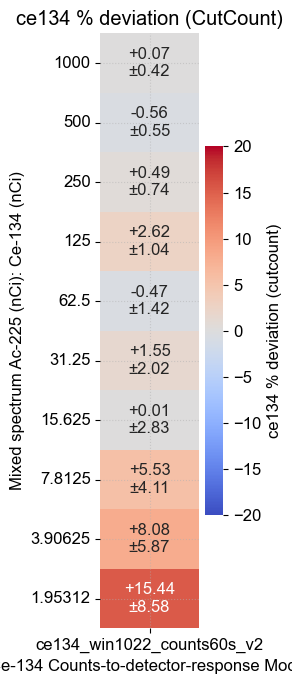

In [ ]:
sub = runs_cc_flat[
    (runs_cc_flat["method_tag"] == "cutcount_single_v1") &
    (runs_cc_flat["ce_eff_name"] == 'ce134_win1022_counts60s_v2')
].copy()


for ISO in ["ce134"]:
    val = sub.pivot_table(
        index="label",
        columns="ce_eff_name",
        values=f"{ISO}_percent_dev",
        aggfunc="mean",
    )

    sig = sub.pivot_table(
        index="label",
        columns="ce_eff_name",
        values=f"{ISO}_percent_dev_sigma",
        aggfunc="mean",
    )

    # Reorder axes (use your existing orders)
    y_order = ["1000", "500", "250", "125", "62.5", "31.25",
            "15.625", "7.8125", "3.90625", "1.95312"]
    x_order = ['ce134_win1022_counts60s_v2']

    val = val.reindex(index=y_order, columns=x_order)
    sig = sig.reindex(index=y_order, columns=x_order)

    annot = val.copy().astype(object)

    for i in range(val.shape[0]):
        for j in range(val.shape[1]):
            v = val.iat[i, j]
            s = sig.iat[i, j]
            if not np.isfinite(v):
                annot.iat[i, j] = ""
            else:
                if np.isfinite(s):
                    annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
                else:
                    annot.iat[i, j] = f"{v:+.2f}"

    vmin, vmax = -20, 20

    plt.figure(figsize=(3, 7))
    ax = sns.heatmap(
        val,
        annot=annot,
        fmt="",
        center=0,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        cbar_kws={"label": f"{ISO} % deviation (cutcount)"}
    )
    ax.set_xlabel("Ce-134 Counts-to-detector-response Model")
    ax.set_ylabel("Mixed spectrum Ac-225 (nCi): Ce-134 (nCi)")
    ax.set_title(f"{ISO} % deviation (CutCount)")
    plt.tight_layout()
    plt.show()
